Successfully generated 1600 valid trajectories.
Rejected 1099 short trajectories during generation.


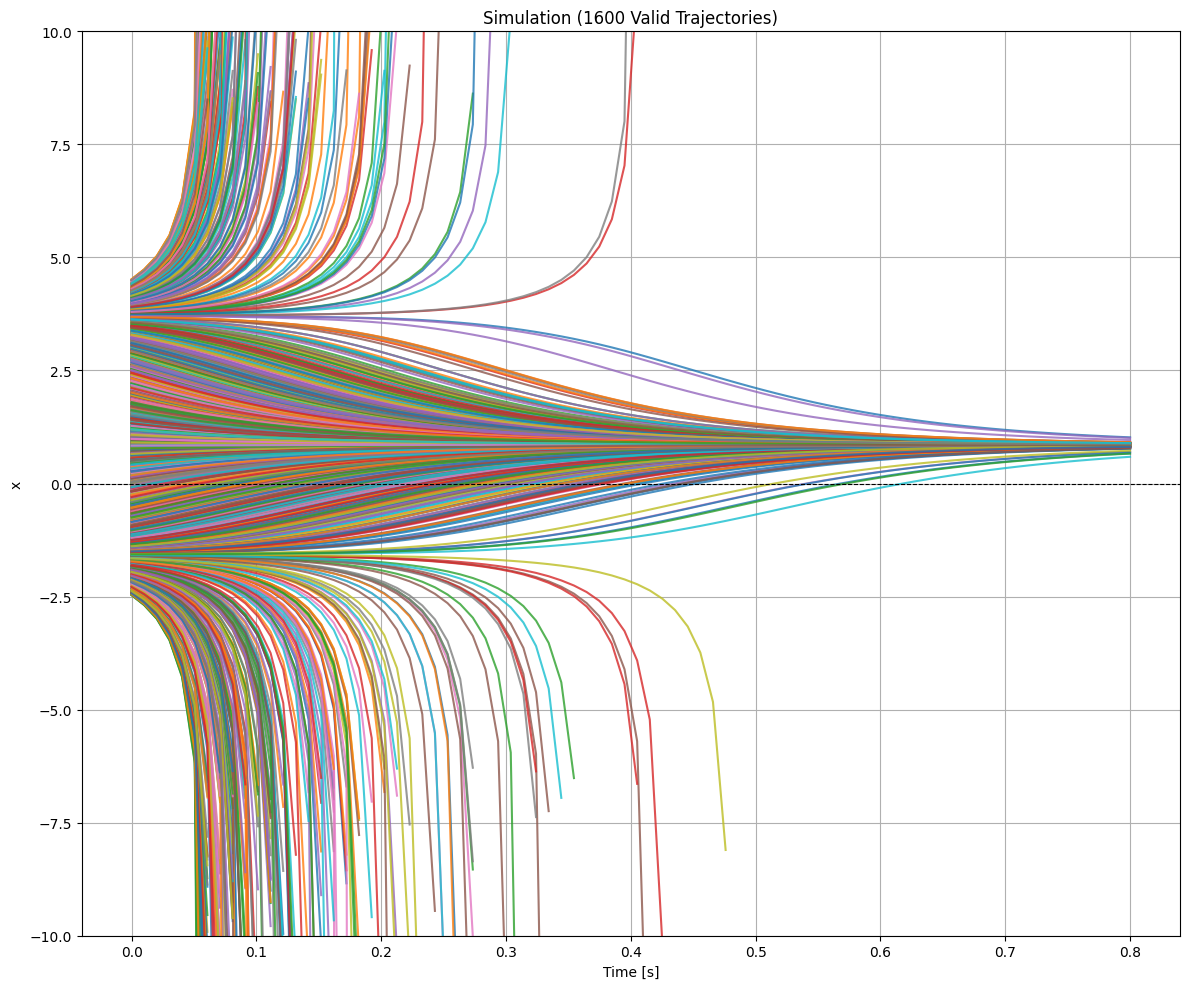

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from numpy.polynomial import Polynomial
# f(x) = x^3 - 4x^2  - 11x + 30
# System has 3 equilibria at [-3, 2, 5]. -3 and 5 are unstable, 2 is stable
coeffs = [5, -4, -3, 1]
poly = Polynomial(coeffs)
def f(x):
    return poly(x)
def polyDyn1d(t, y):
    return f(y)
t_span = (0, 0.8)
t_eval = np.linspace(*t_span, 80)
x0_min, x0_max = -6.0, 6.0
n_trajectories = 1600
solutions = []
all_trajectories = []
fig, (ax1) = plt.subplots(1, figsize=(12, 10))
n_trajectories_target = 1600
min_length = 7
solutions = []
all_trajectories = []
rejected_count = 0


while len(all_trajectories) < n_trajectories_target:
    x0 = np.random.uniform(x0_min, x0_max)
    solution = solve_ivp(polyDyn1d, t_span, [x0], t_eval=t_eval)
    if len(solution.y[0]) >= min_length:
        all_trajectories.append(solution.y[0])
        solutions.append(solution)
        ax1.plot(solution.t, solution.y[0], alpha=0.8)
    else:
        rejected_count += 1
        
print(f"Successfully generated {len(all_trajectories)} valid trajectories.")
print(f"Rejected {rejected_count} short trajectories during generation.")
ax1.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax1.set_title(f"Simulation ({len(all_trajectories)} Valid Trajectories)")
ax1.set_xlabel("Time [s]")
ax1.set_ylabel("x")
ax1.grid()
ax1.set_ylim(-10, 10)
plt.tight_layout()
plt.show()

In [ ]:
import torch.nn as nn
import math
import torch 
from torch.nn import functional as F
import torch.optim as optim
import random


block_size = 7
n_embd = 5
num_heads = 1
head_size = n_embd // num_heads
dropout_rate = 0.2

# Prep Data
inputs = []
for trajectory in all_trajectories:
    for i in range(len(trajectory) - block_size):
        inputs.append(trajectory[i:i + block_size + 1])
training_inputs = inputs[:int(len(inputs)*.75)]
test_inputs = inputs[int(len(inputs)*.75):]


# Train Model
embed = nn.Linear(1, n_embd, bias=False)
w_key = nn.Linear(n_embd, head_size, bias=False)
w_query = nn.Linear(n_embd, head_size, bias=False)
w_value = nn.Linear(n_embd, head_size, bias=False)
w_attn_output = nn.Linear(head_size * num_heads, n_embd, bias=False)
dropout = nn.Dropout(dropout_rate)
norm_attn_gain = nn.Parameter(torch.ones(n_embd))
norm_attn_bias = nn.Parameter(torch.zeros(n_embd))
w_ffn = nn.Linear(n_embd, 4 * n_embd)
w_ffn_output = nn.Linear(4 * n_embd, n_embd)
norm_logits_gain = nn.Parameter(torch.ones(n_embd))
norm_logits_bias = nn.Parameter(torch.zeros(n_embd))
w_logits_output = nn.Linear(n_embd, 1)

params = [
    embed.weight, w_key.weight, w_query.weight, w_value.weight, w_attn_output.weight,
    norm_attn_gain, norm_attn_bias,
    w_ffn.weight, w_ffn.bias, w_ffn_output.weight, w_ffn_output.bias,
    norm_logits_gain, norm_logits_bias,
    w_logits_output.weight, w_logits_output.bias
]
optimizer = optim.Adam(params, lr=0.001)

# Training
n_epochs = 4
for epoch in range(n_epochs):
    epoch_loss = 0
    for input in training_inputs:
        input_sequence = torch.tensor(input, dtype=torch.float32)
        input_data = input_sequence[:block_size]
        input_data = input_data.unsqueeze(-1)  # Go from a single 10 element vector to a matrix of 10 vectors (each of size 1)
        target = input_sequence[-1]
        # Attention Heads
        embedded_input = embed(input_data)
        K, Q, V = w_key(embedded_input), w_query(embedded_input), w_value(embedded_input)
        raw_attention_scores = (Q @ K.transpose(-2,-1)) * (1.0 / math.sqrt(head_size))
        #masked_attention_scores = raw_attention_scores.masked_fill(torch.tril(torch.ones(block_size, block_size)) == 0, float('-inf'))
        attention_probabilities = dropout(F.softmax(raw_attention_scores, dim=-1))
        attention_output = dropout(w_attn_output(attention_probabilities @ V))
        # Add + Norm
        FFN_in_raw = attention_output + embedded_input
        FFN_in_normalized = norm_attn_gain * (FFN_in_raw - FFN_in_raw.mean(dim=-1, keepdim=True)) + norm_attn_bias
        # FFN
        FFN_activations = F.relu(w_ffn(FFN_in_normalized))
        FFN_output = dropout(w_ffn_output(FFN_activations))
        # Add + Norm
        logits_raw = FFN_output + FFN_in_normalized
        logits_normalized = norm_logits_gain * (logits_raw - logits_raw.mean(dim=-1, keepdim=True)) + norm_logits_bias
        # Linear
        logits = w_logits_output(logits_normalized)

        # Backpropagation
        prediction = logits[-1, 0]
        loss = F.mse_loss(prediction, target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch}, Loss: {epoch_loss / len(training_inputs):.6f}")
total_params = 0
for i, p in enumerate(params):
    n = p.numel()
    total_params += n
    print(f"Param {i}: {n} parameters, shape: {p.shape}")
print(f"\nTotal parameters: {total_params}")

Epoch 0, Loss: 0.992218
Epoch 1, Loss: 0.918057
Epoch 2, Loss: 0.877515
Epoch 3, Loss: 0.893401
Param 0: 5 parameters, shape: torch.Size([5, 1])
Param 1: 25 parameters, shape: torch.Size([5, 5])
Param 2: 25 parameters, shape: torch.Size([5, 5])
Param 3: 25 parameters, shape: torch.Size([5, 5])
Param 4: 25 parameters, shape: torch.Size([5, 5])
Param 5: 5 parameters, shape: torch.Size([5])
Param 6: 5 parameters, shape: torch.Size([5])
Param 7: 100 parameters, shape: torch.Size([20, 5])
Param 8: 20 parameters, shape: torch.Size([20])
Param 9: 100 parameters, shape: torch.Size([5, 20])
Param 10: 5 parameters, shape: torch.Size([5])
Param 11: 5 parameters, shape: torch.Size([5])
Param 12: 5 parameters, shape: torch.Size([5])
Param 13: 5 parameters, shape: torch.Size([1, 5])
Param 14: 1 parameters, shape: torch.Size([1])

Total parameters: 356


In [1]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
import numpy as np

chains = []
j = 0
for idx, test_input in enumerate(shuffled_test_inputs[:900]):
    if test_input[0] > -2.5 and test_input[0] < 4.5:
        chain = test_input.tolist()
        chains.append(chain)
        cancel = False
        i = 10
        prediction = 0
        while i < 80 and cancel == False:
            test_input_sequence = jnp.array(test_input, dtype=jnp.float32)
            test_input_data = test_input_sequence[:block_size]
            test_input_data = test_input_data.reshape(-1, 1)
            test_target = test_input_sequence[-1]
            
            test_embedded_input = test_input_data @ params['embed_weight'].T + params['embed_bias']
            K = test_embedded_input @ params['w_key_weight'].T
            Q = test_embedded_input @ params['w_query_weight'].T
            V = test_embedded_input @ params['w_value_weight'].T
            
            raw_attention_scores = (Q @ K.T) * (1.0 / jnp.sqrt(head_size))
            attention_probabilities = jax.nn.softmax(raw_attention_scores, axis=-1)
            attention_output = (attention_probabilities @ V) @ params['w_attn_output_weight'].T + params['w_attn_output_bias']
            
            FFN_in_raw = attention_output + test_embedded_input
            FFN_in_normalized = params['norm_attn_gain'] * (FFN_in_raw - FFN_in_raw.mean(axis=-1, keepdims=True)) + params['norm_attn_bias']
            
            FFN_activations = jax.nn.relu(FFN_in_normalized @ params['w_ffn_weight'].T + params['w_ffn_bias'])
            FFN_output = FFN_activations @ params['w_ffn_output_weight'].T + params['w_ffn_output_bias']
            
            logits_raw = FFN_output + FFN_in_normalized
            logits_normalized = params['norm_logits_gain'] * (logits_raw - logits_raw.mean(axis=-1, keepdims=True)) + params['norm_logits_bias']
            
            logits = logits_normalized @ params['w_logits_output_weight'].T + params['w_logits_output_bias']
            prediction = float(logits[-1, 0])
            chain = chain[1:]
            chain.append(prediction)
            chains[j].append(prediction)
            test_input = np.array(chain[-block_size:], dtype=np.float32)
            i += 1
            if prediction < -5 or prediction > 7.5:
                cancel = True
        j += 1

fig, ax1 = plt.subplots(1, figsize=(12, 10))
for chain in chains:
    t = np.arange(len(chain))
    ax1.plot(t[:block_size], chain[:block_size], color='blue', alpha=0.8)
    ax1.plot(t[block_size-1:], chain[block_size-1:], color='red', alpha=0.8)
ax1.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax1.set_title(f"Neural Network Generated Chains ({len(chains)} Trajectories)")
ax1.set_xlabel("Time Step")
ax1.set_ylabel("Value")
ax1.grid()
ax1.set_ylim(-5, 7.5)
plt.tight_layout()
plt.show()

NameError: name 'shuffled_test_inputs' is not defined

In [23]:
import torch

class EdgeInput():
    def __init__(self, controller, embeddings, index):
        self.controller = controller
        self.embeddings = embeddings
        self.index = index

    def backward(self, lw, uw):
        assert(type(self.index) == int)
        self.controller.final_lw = lw[:, :, self.index, :]
        self.controller.final_uw = uw[:, :, self.index, :]
        _lb = torch.sum(lw * self.embeddings.unsqueeze(0).unsqueeze(0), dim=[-1, -2])
        _ub = torch.sum(uw * self.embeddings.unsqueeze(0).unsqueeze(0), dim=[-1, -2]) 

        self.controller.lb += _lb
        self.controller.ub += _ub

        self.controller.final_lb = self.controller.lb.reshape(_lb.shape).clone()
        self.controller.final_ub = self.controller.ub.reshape(_lb.shape).clone()

        l, u = self.controller.concretize(self.controller.final_lw, self.controller.final_uw)
        l = l.reshape(_lb.shape)
        u = u.reshape(_lb.shape)

        self.controller.lb += l
        self.controller.ub += u
        torch.cpu.empty_cache()

class Controller:
    def __init__(self):
        self.layers = []

    def append(self, layer):
        self.layers.append(layer)

    def compute(self, length, dim):
        self.lb = torch.zeros(length, dim).cpu()
        self.ub = self.lb.clone()
        self.final_lw = self.final_uw = None
        self.final_lb = self.final_ub = None
        for layer in self.layers[::-1]:
            if layer.lw is not None:
                layer.backward()

class Layer:
    def __init__(self, controller, length, dim):
        self.controller = controller
        self.dim = dim
        self.length = length
        self.parents = []
        self.l = self.u = None
        # for back propagation
        self.lw = self.uw = None         
        # bounds of the layer 
        self.final_lw = self.final_uw = None 
        self.final_lb = self.final_ub = None
        self.controller.append(self)

    def add_edge(self, edge):
        self.parents.append(edge)

    def compute(self):
        self.lw = torch.eye(self.dim).cpu()\
            .reshape(1, self.dim, self.dim).repeat(self.length, 1, 1)
        self.uw = self.lw.clone()
        self.controller.compute(self.length, self.dim)
        self.l, self.u = self.controller.lb, self.controller.ub
        self.final_lw, self.final_uw = self.controller.final_lw, self.controller.final_uw
        self.final_lb, self.final_ub = self.controller.final_lb, self.controller.final_ub

    def backward(self):
        for edge in self.parents:
            edge.backward(self.lw, self.uw)
        del(self.lw)
        del(self.uw)
        torch.cpu.empty_cache()
        self.lw, self.uw = None, None

def _bound_input(embeddings, index, eps):
    length, dim = embeddings.shape[0], embeddings.shape[1]
    controller = Controller()
    layer = Layer(controller, length, dim)
    layer.add_edge(EdgeInput(controller, embeddings, index))
    layer.compute()
    return layer

epsilon = 1e-12
index = 1 # apply perturbation at position 2 of sequence 
_bound_input(test_embedded_input, index, epsilon)

IndexError: too many indices for tensor of dimension 3

In [ ]:
epsilon = 1e-12
with torch.no_grad():
    bounds = _bound_input(test_embedded_input, index=index, eps=epsilon) # hard-coded yet
    check("embedding", l=bounds.l, u=bounds.u, std=self.std["embedding_output"][0], verbose=self.debug)

    if self.verbose:
        bounds.print("embedding")

    for i, layer in enumerate(self.encoding_layers):
        attention_scores, attention_probs, bounds = self._bound_layer(bounds, layer)

        std = self.std["attention_scores"][i][0]
        std = std.transpose(0, 1).reshape(1, std.shape[1], -1)
        check("layer {} attention_scores".format(i), 
            l=attention_scores.l, u=attention_scores.u, std=std, verbose=self.debug)
        std = self.std["attention_probs"][i][0]
        std = std.transpose(0, 1).reshape(1, std.shape[1], -1)   
        check("layer {} attention_probs".format(i),
            l=attention_probs.l, u=attention_probs.u, std=std, verbose=self.debug)
        check("layer {}".format(i), l=bounds.l, u=bounds.u, std=self.std["encoded_layers"][i][0], verbose=self.debug)
        
    bounds = self._bound_pooling(bounds, self.pooler)
    check("pooled output", l=bounds.l[:1], u=bounds.u[:1], std=self.std["pooled_output"][0], verbose=self.debug)

    safety = self._bound_classifier(bounds, self.classifier, example["label"])

    for layer in self.controller.layers:
        del(layer.lw)
        del(layer.uw)
        del(layer.final_lw)
        del(layer.final_uw)
        del(layer.final_lb)
        del(layer.final_ub)
    if self.empty_cache:
        torch.cuda.empty_cache()                

    return safety